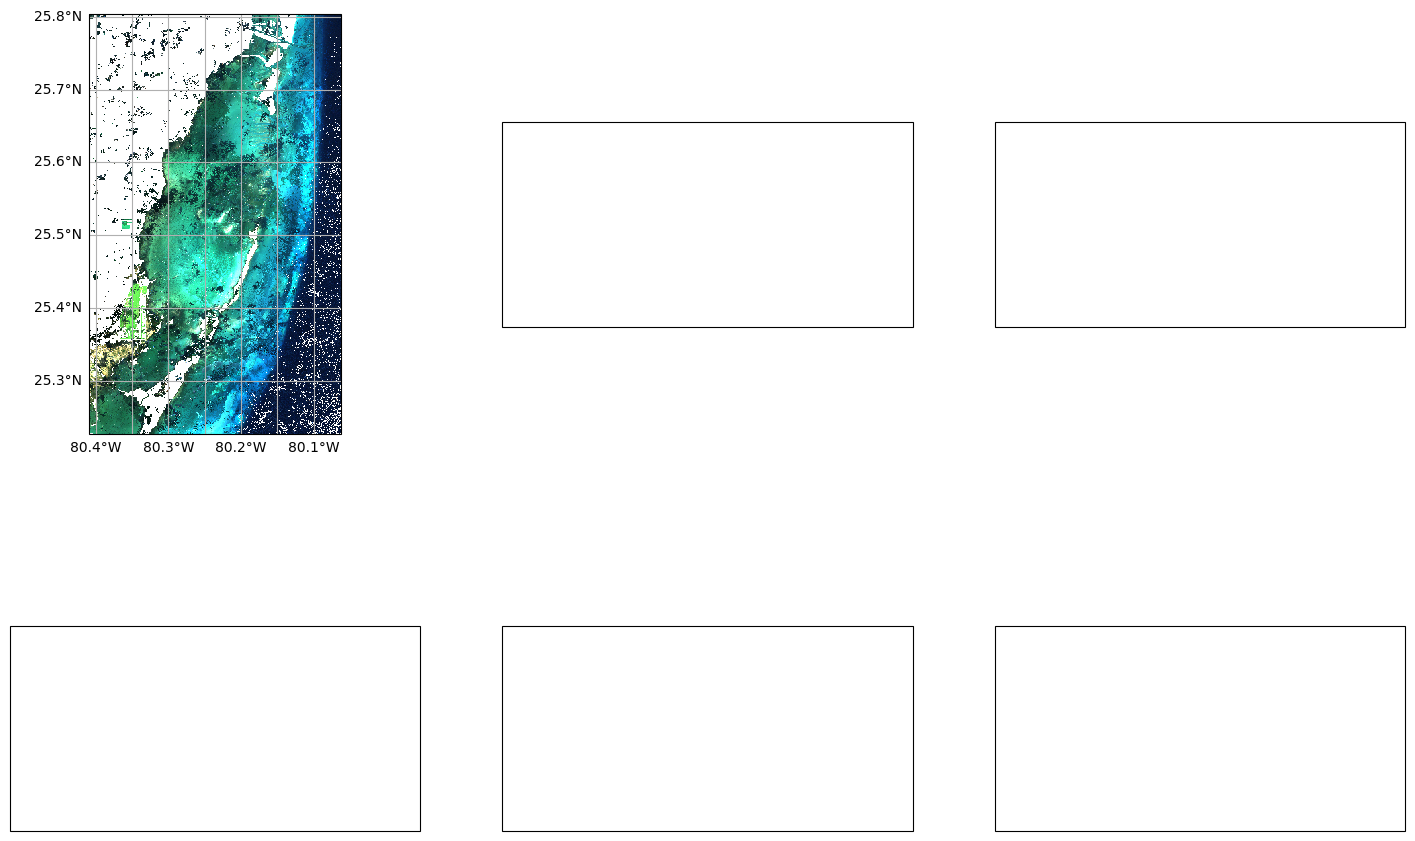

In [4]:
from sensingpy import reader, plot
from cmocean import cm as cmaps
import contextily as ctx
import matplotlib.pyplot as plt
import numpy as np


def plot_SDBs(multi, in_situ, sdb):
    base_letters = ['a', 'b', 'c', 'd', 'e', 'f']
    
    fig, axs = plot.get_geofigure(multi.crs, 2, 3, figsize=(3 * 6, 2 * 6))

    plot.plot_rgb(multi, 'Rrs_B4', 'Rrs_B3', 'Rrs_B2', axs[0, 0], brightness = 30)

    _, gl = plot.add_gridlines(multi.crs, axs[0, 0])
    return fig


multi_images = [
    r"E:\Master\bathymetry\multi_images\miami_all_area__epsg4759.tif",
]

in_situs = [
    r'E:\Master\bathymetry\in_situs\LIDAR_NOAA\LIDAR_NOAA.tif',
]

ODW_MLs = [
    r"E:\Master\masks\ML\miami_all_area__epsg4759.tif",
]

ODW_CSs = [
    r"E:\Master\masks\CS\miami_all_area__epsg4759.tif",
]

ODW_CS_MLs = [
    r"E:\Master\masks\ML\Bagging_MLP\miami_all_area__epsg4759.tif",
]
SDBs = [
    r"E:\Master\bathymetry\sdbs\miami_all_area__epsg4759.tif",
]


for multi, in_situ, odw_cs, odw_ml, odw_cs_ml, sdb, name in zip(multi_images, in_situs, ODW_CSs, ODW_MLs, ODW_CS_MLs, SDBs, ['florida']):
    multi = reader.open(multi).dropna().resample(10)
    in_situ = reader.open(in_situ).align(multi)
    odw_cs = reader.open(odw_cs).align(multi)
    odw_ml = reader.open(odw_ml).align(multi)
    odw_cs_ml = reader.open(odw_cs_ml).align(multi)

    sdb = reader.open(sdb).align(multi)

    data = sdb.select('SDB Switching')
    data[odw_cs.select('ODW') == 0] = np.nan
    sdb.add_band('ODW_CS', data)

    data = sdb.select('SDB Switching')
    data[odw_ml.select('ODW') == 0] = np.nan
    sdb.add_band('ODW_ML', data)
    
    data = sdb.select('SDB Switching')
    data[odw_cs_ml.select('ODW') == 0] = np.nan
    sdb.add_band('ODW_CS_ML', data)

    in_situ = in_situ.add_band('Band 1', -in_situ.select('Band 1'))

    fig = plot_SDBs(multi, in_situ, sdb)